In [86]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
sns.set_style("whitegrid")

In [87]:
def set_style():
    mpl.rcParams.update({
        # Export / vector text
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography (JMLR-ish)
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 12,

        # Clean axes
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })


In [88]:
result_path = Path("sens_res/simulation_results_python.pkl") # 001

with open(result_path, "rb") as f:
    obj = pickle.load(f)

config = obj["config"]
results = obj["results"]

print(config.keys())
print(list(results.keys())[:5])

dict_keys(['simulation', 'gp_parameters', 'target_quantile', 'delta_logl_values', 'threshold_approximation', 'inducing_points', 'target_coverage', 'train_split', 'models', 'models_with_hyperparams', 'gpb_approxs', 'n_epochs', 'lr', 'name_dict', 'likelihood_dict', 'all_models'])
['gaussian_1000_2', 'gaussian_1000_5', 'gaussian_10000_2', 'gaussian_10000_5', 't_1000_2']


In [89]:
rows = []

for config_key, rep_dict in results.items():
    # example: "gaussian_1000_2" or "gaussian_heteroscedastic_10000_5"
    parts = config_key.split("_")
    sample_size = int(parts[-2])
    input_dim = int(parts[-1])
    likelihood = "_".join(parts[:-2])

    for replicate, model_dict in rep_dict.items():
        for model_name, metrics in model_dict.items():
            rows.append({
                "config_key": config_key,
                "replicate": replicate,
                "likelihood": likelihood,
                "sample_size": sample_size,
                "input_dim": input_dim,
                "model": model_name,
                "delta_logl": metrics.get("delta_logl", np.nan),
                "rmse": metrics.get("rmse", np.nan),
                "quantile_loss": metrics.get("quantile_loss", np.nan),
                "interval_loss": metrics.get("interval_loss", np.nan),
                "coverage": metrics.get("coverage", np.nan),
                "width": metrics.get("width", np.nan),
                "bias": metrics.get("bias", np.nan),
                "empirical_quantile": metrics.get("empirical_quantile", np.nan),
                "time": metrics.get("time", np.nan),
                "lengthscale": metrics.get("lengthscale", np.nan),
                "signal_variance": metrics.get("signal_variance", np.nan),
                "noise_variance": metrics.get("noise_variance", np.nan),
            })

df = pd.DataFrame(rows)
df.head()

,config_key,replicate,likelihood,sample_size,input_dim,model,delta_logl,rmse,quantile_loss,interval_loss,coverage,width,bias,empirical_quantile,time,lengthscale,signal_variance,noise_variance
0,gaussian_1000_2,8,gaussian,1000,2,gpboost_cc_dll_0.01,0.01,0.215233,0.133869,4.784467,0.572,0.356646,-0.035952,0.74,3.016920,0.297101,0.641495,"Param. 0.108699 Name: scale, dtype: float64"
1,gaussian_1000_2,8,gaussian,1000,2,gpboost_cc_dll_0.03,0.03,0.215233,0.133869,4.784467,0.572,0.356646,-0.035952,0.74,2.938919,0.297101,0.641495,"Param. 0.108699 Name: scale, dtype: float64"
2,gaussian_1000_2,8,gaussian,1000,2,gpboost_cc_dll_0.1,0.10,0.215233,0.133869,4.784467,0.572,0.356646,-0.035952,0.74,2.907528,0.297101,0.641495,"Param. 0.108699 Name: scale, dtype: float64"
3,gaussian_1000_2,8,gaussian,1000,2,gpboost_cc_dll_0.3,0.30,0.215233,0.133869,4.784467,0.572,0.356646,-0.035952,0.74,2.920156,0.297101,0.641495,"Param. 0.108699 Name: scale, dtype: float64"
4,gaussian_1000_2,8,gaussian,1000,2,gpboost_cc_dll_1.0,1.00,0.215233,0.133869,4.784467,0.572,0.356646,-0.035952,0.74,2.778759,0.297101,0.641495,"Param. 0.108699 Name: scale, dtype: float64"


In [90]:
#df = df[df["sample_size"] == 1000].copy()

In [91]:
num_cols = [
    "delta_logl", "rmse", "quantile_loss", "interval_loss", "coverage", "width",
    "bias", "empirical_quantile", "time", "lengthscale", "signal_variance", "noise_variance"
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values(
    ["likelihood", "sample_size", "input_dim", "delta_logl", "replicate"]
).reset_index(drop=True)

df.shape

(1150, 18)

In [92]:
def se(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))

summary = (
    df.groupby(["likelihood", "sample_size", "input_dim", "delta_logl"], as_index=False)
      .agg(
          rmse_mean=("rmse", "mean"),
          rmse_se=("rmse", se),
          time_mean=("time", "mean"),
          time_se=("time", se),
          qloss_mean=("quantile_loss", "mean"),
          qloss_se=("quantile_loss", se),
          lengthscale_mean=("lengthscale", "mean"),
          lengthscale_se=("lengthscale", se),
          signal_variance_mean=("signal_variance", "mean"),
          signal_variance_se=("signal_variance", se),
          noise_variance_mean=("noise_variance", "mean"),
          noise_variance_se=("noise_variance", se),
      )
)

summary.head()

,likelihood,sample_size,input_dim,delta_logl,rmse_mean,rmse_se,time_mean,time_se,qloss_mean,qloss_se,lengthscale_mean,lengthscale_se,signal_variance_mean,signal_variance_se,noise_variance_mean,noise_variance_se
0,gaussian,1000,2,0.01,0.215280,0.003098,4.246708,0.498453,0.140731,0.002157,0.216873,0.021668,0.752524,0.031266,NaN,NaN
1,gaussian,1000,2,0.03,0.215280,0.003098,4.205005,0.509814,0.140731,0.002157,0.216873,0.021668,0.752524,0.031266,NaN,NaN
2,gaussian,1000,2,0.10,0.216962,0.003550,3.882881,0.636294,0.141249,0.002334,0.207991,0.022772,0.763784,0.033237,NaN,NaN
3,gaussian,1000,2,0.30,0.215733,0.003139,4.078191,0.547437,0.140907,0.002205,0.210060,0.022205,0.761225,0.032458,NaN,NaN
4,gaussian,1000,2,1.00,0.219978,0.005671,4.415838,0.537779,0.141914,0.002694,0.205898,0.023519,0.791780,0.050199,NaN,NaN


In [93]:
def plot_metric(summary_df, metric_mean, metric_se, ylabel):
    set_style()
    likelihoods = sorted(summary_df["likelihood"].dropna().unique())
    sample_sizes = sorted(summary_df["sample_size"].dropna().unique())
    input_dims = sorted(summary_df["input_dim"].dropna().unique())

    # combine sample size and dimension into columns
    col_settings = [(n, d) for n in sample_sizes for d in input_dims]

    all_x = sorted(summary_df["delta_logl"].dropna().unique())
    x_pos = np.arange(len(all_x))

    fig, axes = plt.subplots(
        len(likelihoods),
        len(col_settings),
        figsize=(4.5 * len(col_settings), 3.8 * len(likelihoods)),
        squeeze=False,
        sharey="row",
        sharex="col"
    )

    for i, lik in enumerate(likelihoods):
        for j, (n, d) in enumerate(col_settings):
            ax = axes[i, j]

            sub = summary_df[
                (summary_df["likelihood"] == lik) &
                (summary_df["sample_size"] == n) &
                (summary_df["input_dim"] == d)
            ].sort_values("delta_logl")

            sub_pos = [all_x.index(x) for x in sub["delta_logl"]]

            ax.errorbar(
                sub_pos,
                sub[metric_mean],
                yerr=sub[metric_se],
                marker="o",
                capsize=3,
                color="black"
            )

            ax.set_xticks(x_pos)
            ax.set_xticklabels([f"{x:.0e}" for x in all_x], rotation=45)
            ax.grid(True, alpha=0.3)

            if i == len(likelihoods) - 1:
                ax.set_xlabel("Minimum log-likelihood drop")
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")

            ax.set_title(f"{lik}, n = {n}, d = {d}")

    

    plt.tight_layout(rect=(0.04, 0, 1, 1))
    plt.show()

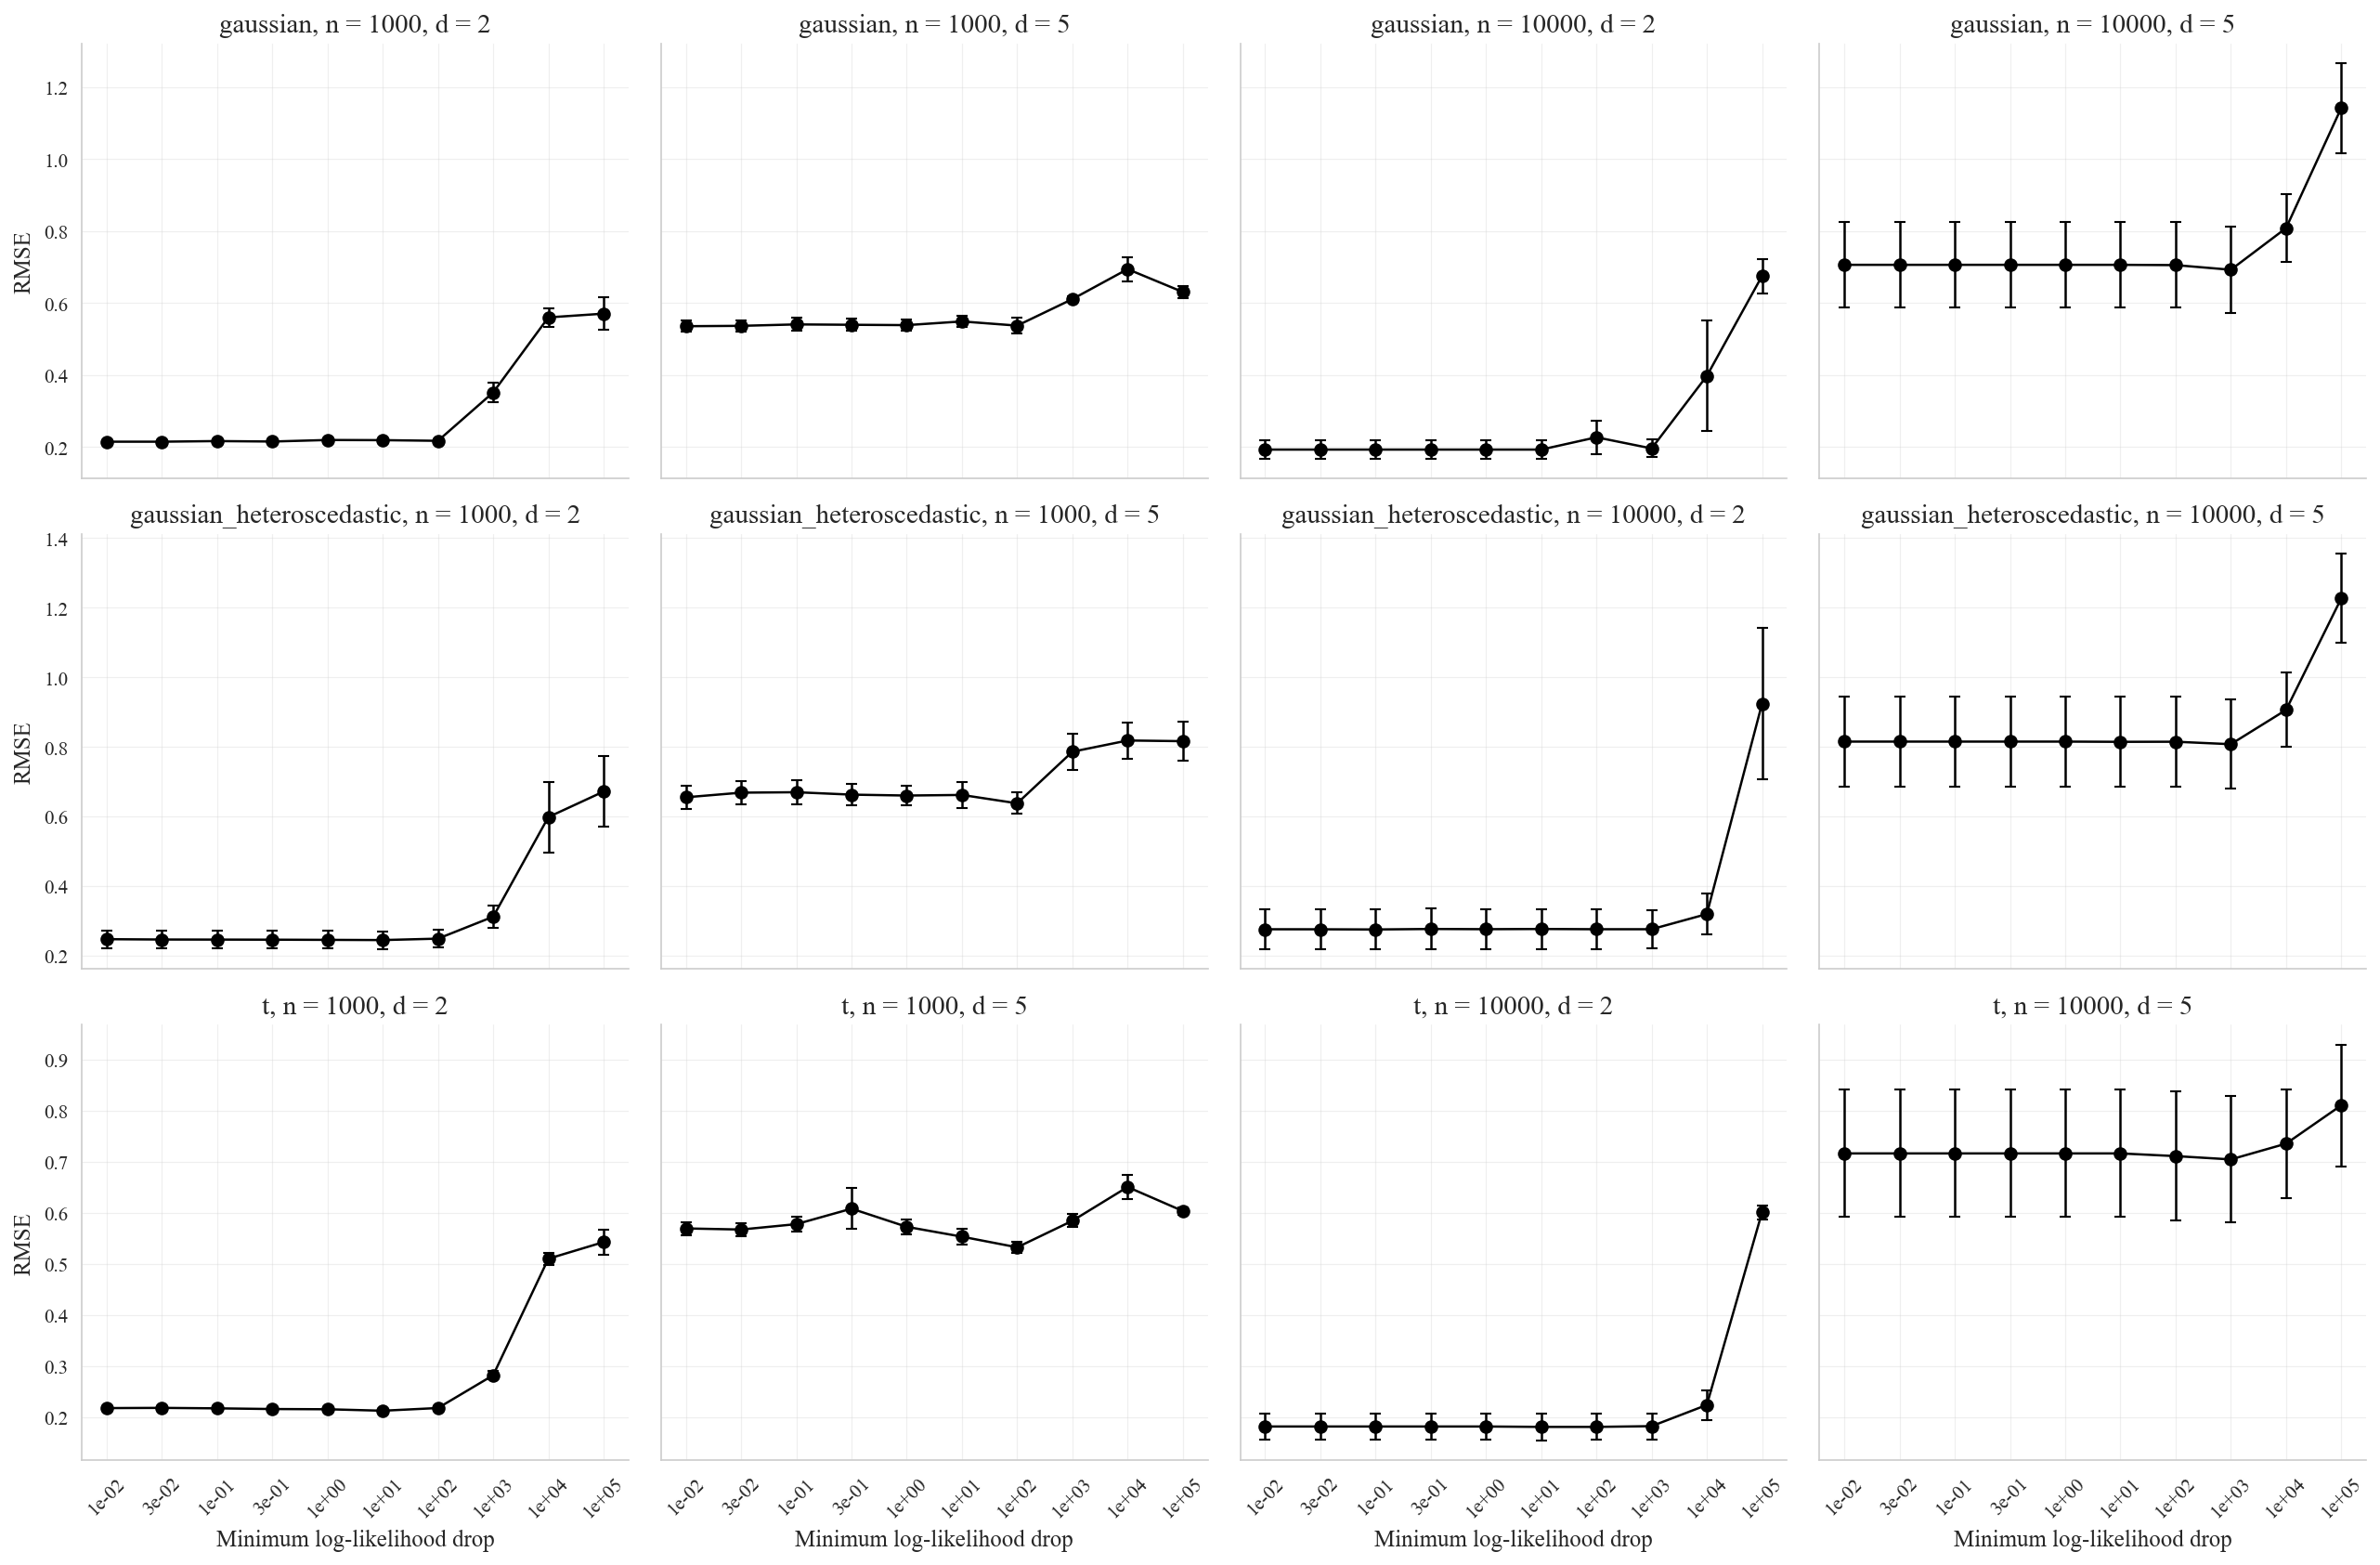

In [94]:
plot_metric(summary, "rmse_mean", "rmse_se", "RMSE")

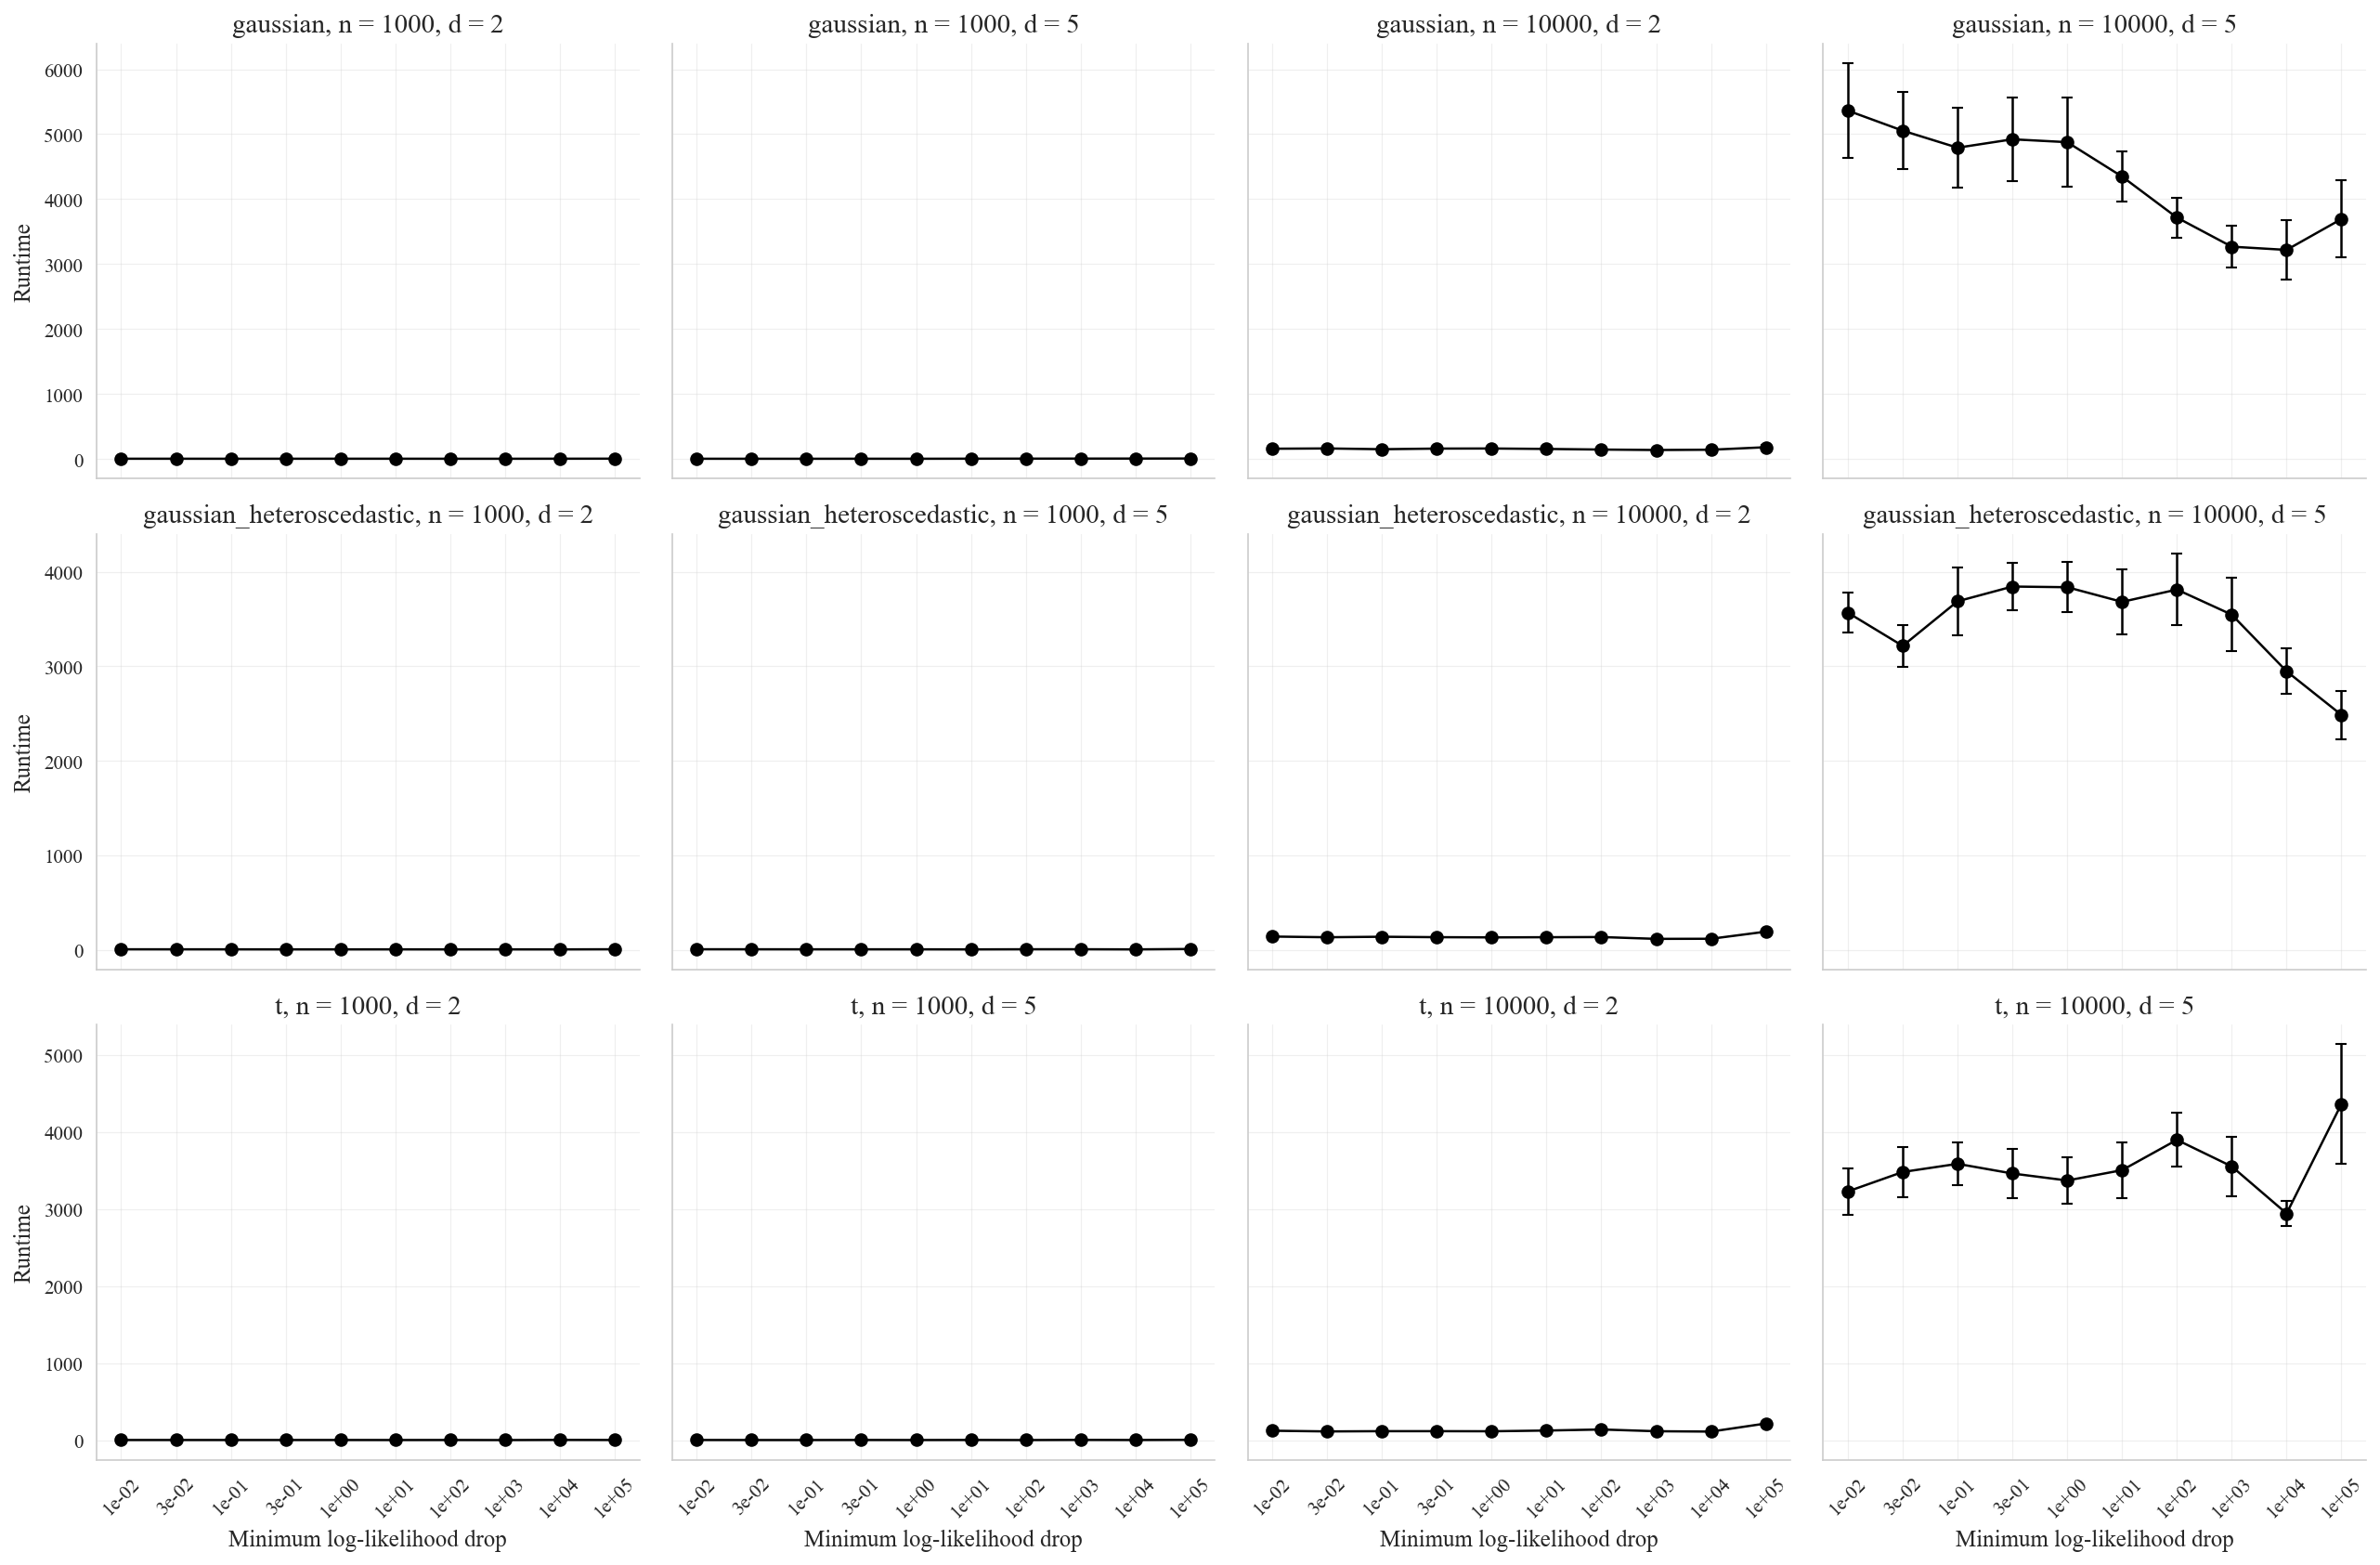

In [95]:
plot_metric(summary, "time_mean", "time_se", "Runtime")

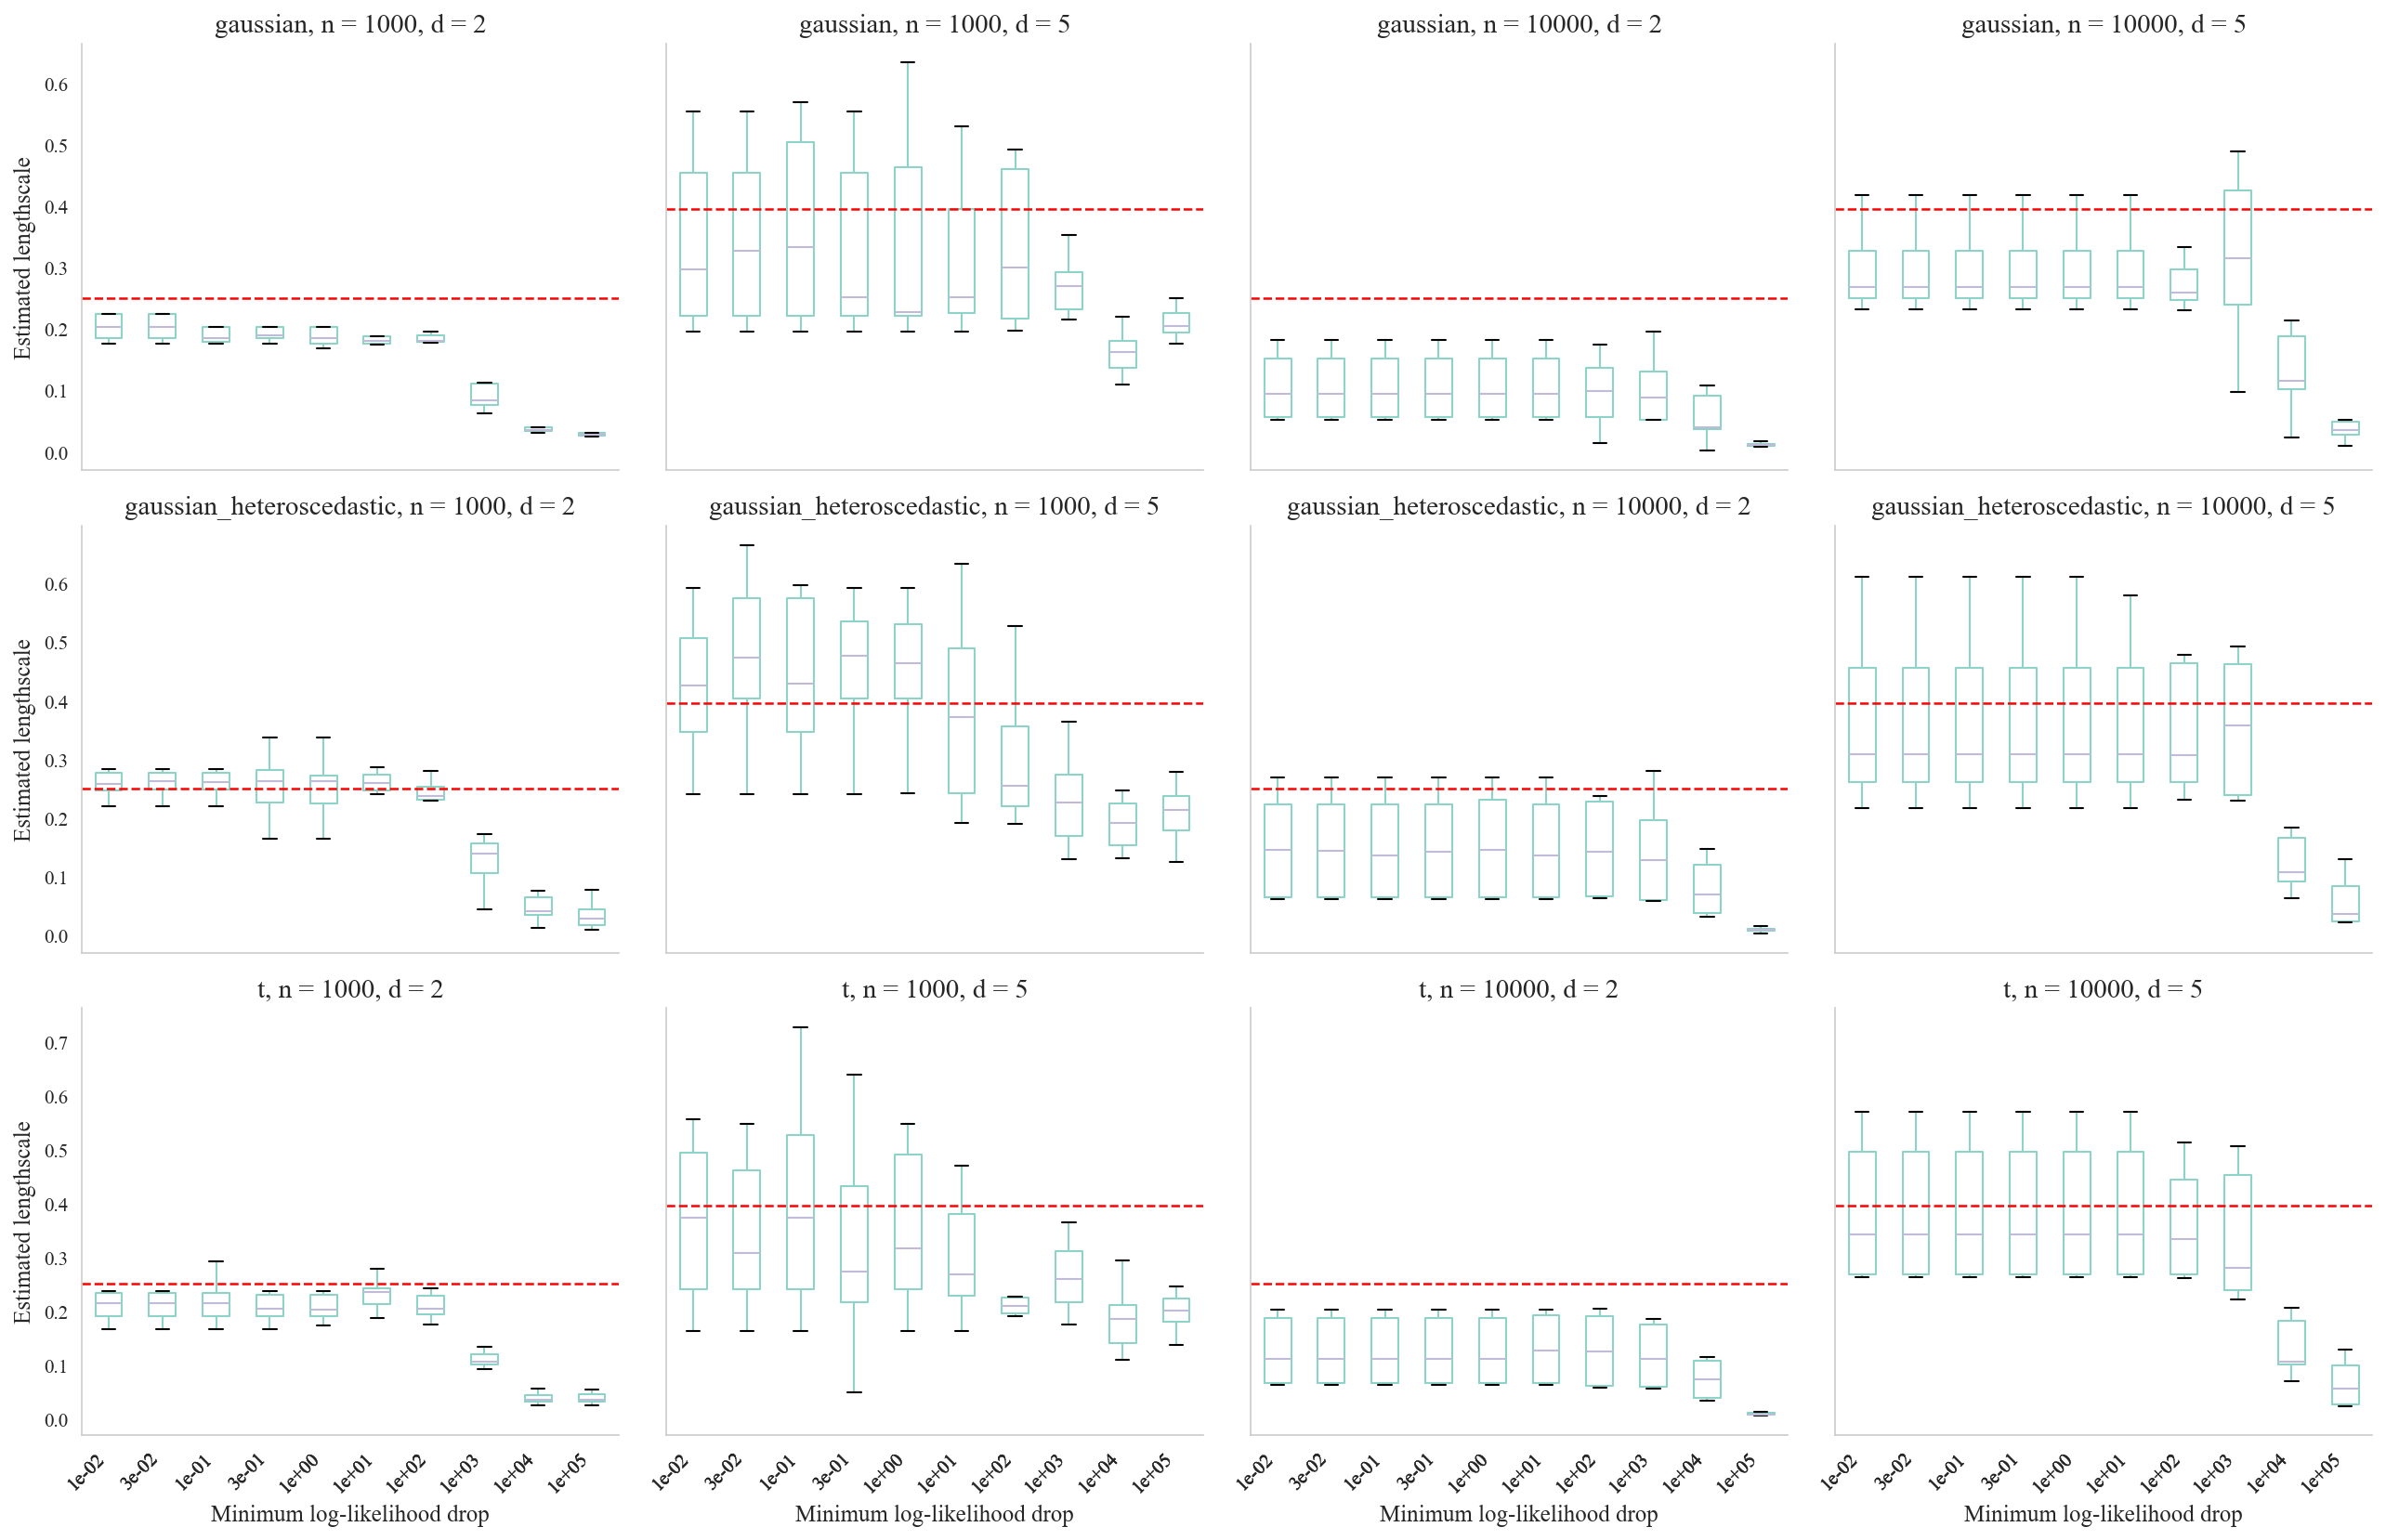

In [97]:
likelihoods = sorted(df["likelihood"].dropna().unique())
sample_sizes = sorted(df["sample_size"].dropna().unique())
input_dims = sorted(df["input_dim"].dropna().unique())
col_settings = [(n, d) for n in sample_sizes for d in input_dims]

param = "lengthscale" #"signal_variance" #"lengthscale"

fig, axes = plt.subplots(
    len(likelihoods),
    len(col_settings),
    figsize=(4.5 * len(col_settings), 3.8 * len(likelihoods)),
    squeeze=False,
    sharey="row",
    sharex="col"
)
set_style()
for i, lik in enumerate(likelihoods):
    for j, (n, d) in enumerate(col_settings):
        ax = axes[i, j]

        sub = df[
            (df["likelihood"] == lik) &
            (df["sample_size"] == n) &
            (df["input_dim"] == d)
        ][["delta_logl", param]].dropna().copy()

        order = sorted(sub["delta_logl"].unique())
        labels = [f"{x:.0e}" for x in order]
        sub["delta_logl_label"] = pd.Categorical(
            [f"{x:.0e}" for x in sub["delta_logl"]],
            categories=labels,
            ordered=True
        )

        sub.boxplot(
            column=param,
            by="delta_logl_label",
            ax=ax,
            grid=False,
            showfliers=False
        )

        if param == "lengthscale":
            ax.axhline(0.25*np.sqrt(d/2), linestyle="--", color="red")
        else:
            ax.axhline(1.0, linestyle="--", color="red")
    
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)
            tick.set_ha("right")

        if i == len(likelihoods) - 1:
            ax.set_xlabel("Minimum log-likelihood drop")
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(f"Estimated {param}")
        else:
            ax.set_ylabel("")

        ax.set_title(f"{lik}, n = {n}, d = {d}")



plt.suptitle("")
plt.tight_layout(rect=(0.04, 0, 1, 1))
plt.show()